In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint
import warnings

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("heart_disease_dataset.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.drop(columns='id',axis=1,inplace=True)

In [ ]:
rename_columns = {
    'age': 'age',
    'sex': 'gender',
    'cp': 'chest_pain_type',
    'trestbps': 'resting_blood_pressure',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'resting_ecg',
    'thalch': 'max_heart_rate',
    'exang': 'exercise_induced_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'major_vessels_colored',
    'thal': 'thalassemia',
    'num': 'heart_disease'
}
df.rename(columns=rename_columns,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      920 non-null    int64  
 1   gender                   920 non-null    object 
 2   dataset                  920 non-null    object 
 3   chest_pain_type          920 non-null    object 
 4   resting_blood_pressure   861 non-null    float64
 5   cholesterol              890 non-null    float64
 6   fasting_blood_sugar      830 non-null    object 
 7   resting_ecg              918 non-null    object 
 8   max_heart_rate           865 non-null    float64
 9   exercise_induced_angina  865 non-null    object 
 10  st_depression            858 non-null    float64
 11  st_slope                 611 non-null    object 
 12  major_vessels_colored    309 non-null    float64
 13  thalassemia              434 non-null    object 
 14  heart_disease            9

In [ ]:
df.describe()

,age,resting_blood_pressure,cholesterol,max_heart_rate,st_depression,major_vessels_colored,heart_disease
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


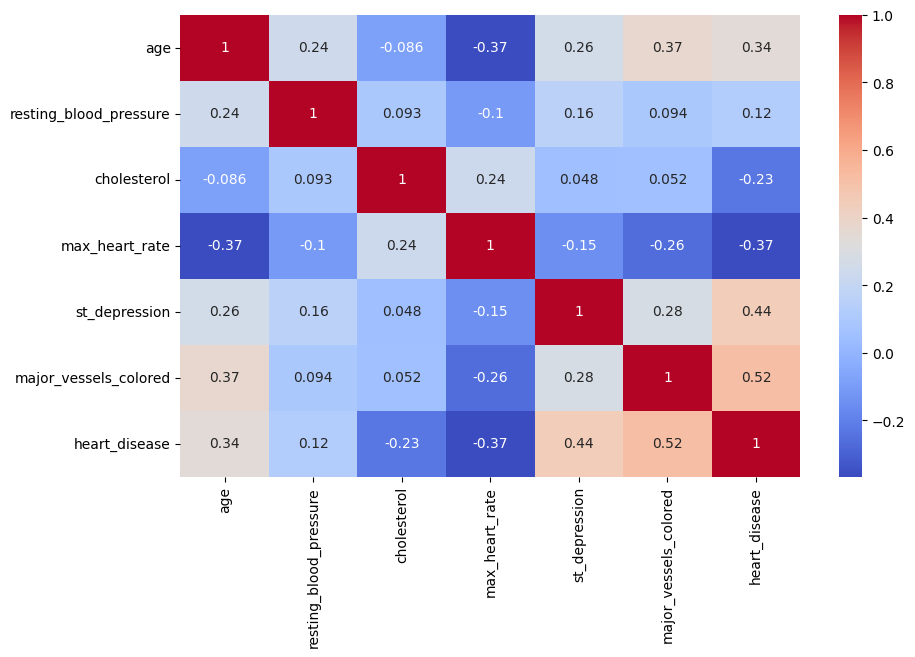

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df.isna().sum()

,0
age,0
gender,0
dataset,0
chest_pain_type,0
resting_blood_pressure,59
cholesterol,30
fasting_blood_sugar,90
resting_ecg,2
max_heart_rate,55
exercise_induced_angina,55


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
#remove duplicate instances
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

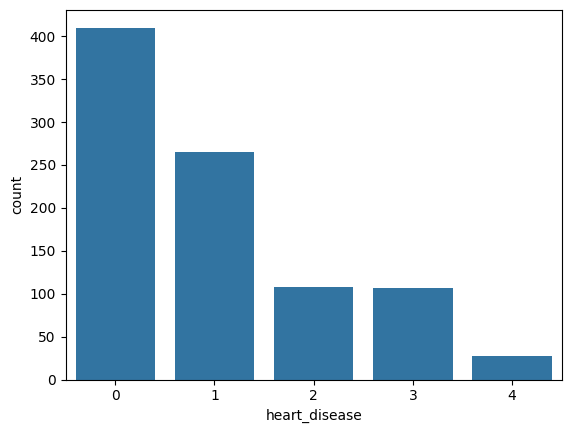

In [ ]:
sns.countplot(x='heart_disease',data=df)
plt.show()

In [ ]:
#converting to binary classificaition
# 0 - No disease
# 1,2,3,4 - disease

df['heart_disease'] = df['heart_disease'].apply(lambda x:0 if x==0 else 1).astype('int')

In [ ]:
df['heart_disease'].value_counts()

,count
heart_disease,
1,508
0,410


In [ ]:
X = df.drop('heart_disease',axis=1)
y = df['heart_disease']

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

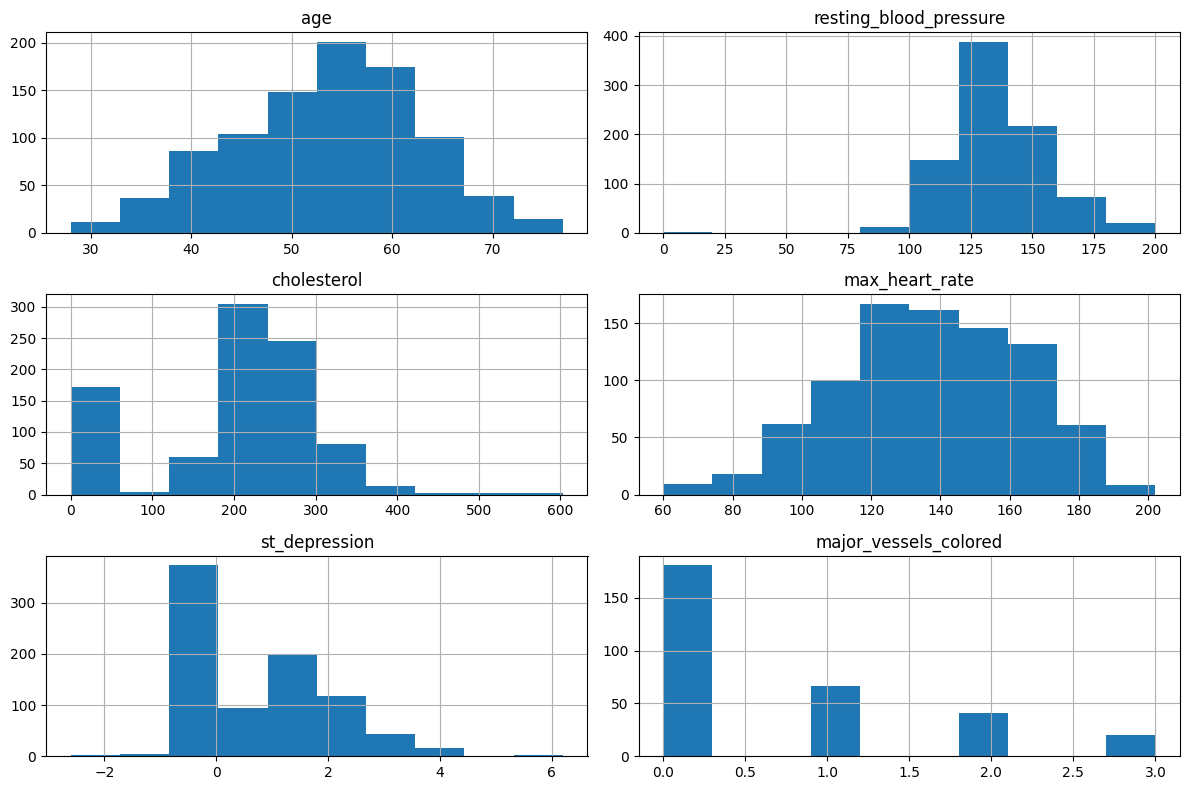

In [ ]:
df[numeric_features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19,stratify=y)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=19),
    "Random Forest": RandomForestClassifier(random_state=19),
    "XGBoost": XGBClassifier(eval_metric='logloss',random_state=19),
    "CatBoost": CatBoostClassifier(verbose=0,random_state=19),
    "LightGBM": LGBMClassifier(random_state=19,verbose=-1)
}

In [ ]:

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    results[name] = auc

    print(name)
    print("ROC-AUC:", auc)

Logistic Regression
ROC-AUC: 0.8762553802008608
Random Forest
ROC-AUC: 0.8660927785748446
XGBoost
ROC-AUC: 0.8567670970827355
CatBoost
ROC-AUC: 0.8870157819225251
LightGBM
ROC-AUC: 0.8699186991869918


In [ ]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=19)

In [ ]:
# Models
models = {
    "CatBoost": CatBoostClassifier(verbose=0,random_state=19),
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=19),
    "LightGBM": LGBMClassifier(random_state=19,verbose=-1),
    "Random Forest": RandomForestClassifier(random_state=19),
    "XGBoost": XGBClassifier(eval_metric="logloss",random_state=19),
}


In [ ]:
# Hyperparameter spaces
param_distributions = {
    "Logistic Regression": {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"],
        "model__class_weight": [None, "balanced"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 3, 5, 7, 10, 15],
        "model__min_samples_split": [2, 5, 10, 15],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": [None, "balanced"]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__gamma": [0, 0.1, 0.3, 0.5],
        "model__reg_alpha": [0, 0.1, 0.5, 1],
        "model__reg_lambda": [0.5, 1, 1.5, 2]
    },

    "CatBoost": {
        "model__iterations": [100, 200, 300, 500],
        "model__depth": [3, 4, 5, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__l2_leaf_reg": [1, 3, 5, 7, 9],
        "model__border_count": [32, 64, 128]
    },

    "LightGBM": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__num_leaves": [15, 31, 50, 70],
        "model__max_depth": [-1, 3, 5, 7, 10],
        "model__min_child_samples": [10, 20, 30, 50],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_alpha": [0, 0.1, 0.5, 1],
        "model__reg_lambda": [0, 0.1, 0.5, 1]
    }
}

In [ ]:
tuned_models = {}
tuning_results = []

for model_name, model in models.items():

    print(f"Running RandomizedSearchCV for {model_name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions[model_name],
        n_iter=30,
        scoring="roc_auc",
        cv=cv,
        random_state=19,
        n_jobs=-1,
        verbose=0
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    tuned_models[model_name] = best_model

    y_proba = best_model.predict_proba(X_test)[:, 1]
    test_roc_auc = roc_auc_score(y_test, y_proba)

    tuning_results.append({
        "Model": model_name,
        "Best CV ROC-AUC": random_search.best_score_,
        "Test ROC-AUC": test_roc_auc,
        "Best Parameters": random_search.best_params_
    })

    print(f"\n{model_name}")
    print("Best CV ROC-AUC:", random_search.best_score_)
    print("Test ROC-AUC:", test_roc_auc)
    print("Best Parameters:", random_search.best_params_)
    print("-" * 80)

Running RandomizedSearchCV for CatBoost...

CatBoost
Best CV ROC-AUC: 0.9085189466761282
Test ROC-AUC: 0.8867766618842658
Best Parameters: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 7, 'model__iterations': 500, 'model__depth': 6, 'model__border_count': 128}
--------------------------------------------------------------------------------
Running RandomizedSearchCV for Logistic Regression...

Logistic Regression
Best CV ROC-AUC: 0.9110722680912383
Test ROC-AUC: 0.8791248206599713
Best Parameters: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__class_weight': 'balanced', 'model__C': 100}
--------------------------------------------------------------------------------
Running RandomizedSearchCV for LightGBM...

LightGBM
Best CV ROC-AUC: 0.9037714087578586
Test ROC-AUC: 0.8885700621712098
Best Parameters: {'model__subsample': 0.8, 'model__reg_lambda': 0.1, 'model__reg_alpha': 0, 'model__num_leaves': 31, 'model__n_estimators': 100, 'model__min_child_samples': 50, 'mo

In [ ]:
tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values(by="Test ROC-AUC",ascending=False)
tuning_results_df

,Model,Best CV ROC-AUC,Test ROC-AUC,Best Parameters
4,XGBoost,0.904246,0.889646,"{'model__subsample': 0.8, 'model__reg_lambda':..."
2,LightGBM,0.903771,0.888570,"{'model__subsample': 0.8, 'model__reg_lambda':..."
0,CatBoost,0.908519,0.886777,"{'model__learning_rate': 0.01, 'model__l2_leaf..."
3,Random Forest,0.902318,0.883070,"{'model__n_estimators': 300, 'model__min_sampl..."
1,Logistic Regression,0.911072,0.879125,"{'model__solver': 'liblinear', 'model__penalty..."


In [ ]:
best_model_name = tuning_results_df.iloc[0]["Model"]
best_final_model = tuned_models[best_model_name]

print("Best Final Model:", best_model_name)

Best Final Model: XGBoost


ROC-AUC: 0.8896461023433764
Accuracy: 0.8369565217391305
Precision: 0.8529411764705882
Recall: 0.8529411764705882
F1 Score: 0.8529411764705882

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        82
           1       0.85      0.85      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:


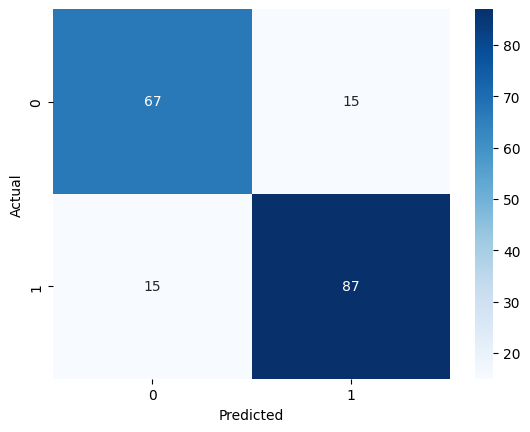

In [ ]:
y_pred = best_final_model.predict(X_test)
y_proba = best_final_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

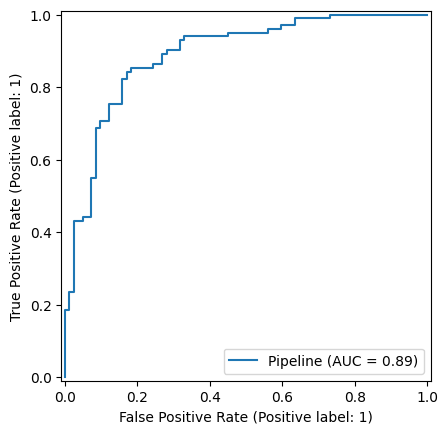

In [ ]:
RocCurveDisplay.from_estimator(
    best_final_model,
    X_test,
    y_test
)
plt.show()

The project demonstrates an end-to-end ML workflow including preprocessing, model comparison, cross-validation, and hyperparameter tuning for heart disease prediction.